# Бэктест SMA-стратегии на BTC

Проверяю, обгоняет ли стратегия пересечения скользящих средних простое «купил и держал».

**Что внутри:**
1. Загрузка дневных свечей BTC
2. Проверка качества данных
3. Индикатор SMA 20 / SMA 50
4. Бэктест с учётом комиссий и реального момента исполнения
5. Метрики и сравнение с buy & hold
6. Чувствительность к параметрам

Автор: Надыр Калантаров

## 0. Импорты

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Данные

Дневные свечи BTC/USDT с публичного API биржи, ключи не нужны. Пробую несколько источников
по очереди на случай, если один недоступен.

Результат кэширую в CSV: иначе при каждом запуске данные разные и цифры в выводах
не сходятся с текстом.

In [6]:
CSV_PATH = 'btc_daily.csv'


def load_bybit():
    url = 'https://api.bybit.com/v5/market/kline'
    params = {'category': 'spot', 'symbol': 'BTCUSDT', 'interval': 'D', 'limit': 1000}
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    rows = r.json()['result']['list']
    df = pd.DataFrame(rows, columns=['ts', 'open', 'high', 'low', 'close', 'volume', 'turnover'])
    df['date'] = pd.to_datetime(df['ts'].astype('int64'), unit='ms')
    for c in ['open', 'high', 'low', 'close', 'volume']:
        df[c] = df[c].astype(float)
    return df[['date', 'open', 'high', 'low', 'close', 'volume']].sort_values('date')


def load_binance():
    url = 'https://api.binance.com/api/v3/klines'
    params = {'symbol': 'BTCUSDT', 'interval': '1d', 'limit': 1000}
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    df = pd.DataFrame(r.json(), columns=[
        'ts', 'open', 'high', 'low', 'close', 'volume',
        'close_ts', 'qav', 'trades', 'tbb', 'tbq', 'ignore'])
    df['date'] = pd.to_datetime(df['ts'], unit='ms')
    for c in ['open', 'high', 'low', 'close', 'volume']:
        df[c] = df[c].astype(float)
    return df[['date', 'open', 'high', 'low', 'close', 'volume']].sort_values('date')


def load_yahoo():
    import yfinance as yf
    df = yf.download('BTC-USD', period='1000d', interval='1d', progress=False, auto_adjust=False)
    df = df.reset_index()
    df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df.columns]
    return df[['date', 'open', 'high', 'low', 'close', 'volume']]


def get_data():
    if os.path.exists(CSV_PATH):
        print('читаю из кэша', CSV_PATH)
        return pd.read_csv(CSV_PATH, parse_dates=['date'])
    for name, fn in [('bybit', load_bybit), ('binance', load_binance), ('yahoo', load_yahoo)]:
        try:
            df = fn()
            print('данные загружены с', name)
            df.to_csv(CSV_PATH, index=False)
            return df
        except Exception as e:
            print(name, 'не сработал:', type(e).__name__, e)
    raise RuntimeError('ни один источник не доступен')


df = get_data().reset_index(drop=True)
print(f'\nстрок: {len(df)}')
print(f'период: {df.date.min().date()} - {df.date.max().date()}')
df.head()

данные загружены с bybit

строк: 1000
период: 2024-01-03 - 2026-09-28


,date,open,high,low,close,volume
0,2024-01-03,"44,950.95","45,507.99","40,222.10","42,842.00","27,469.44"
1,2024-01-04,"42,842.00","44,791.89","42,622.37","44,151.20","11,226.16"
2,2024-01-05,"44,151.20","44,369.19","42,267.44","44,147.05","14,167.41"
3,2024-01-06,"44,147.05","44,208.95","43,397.02","43,970.00","4,453.13"
4,2024-01-07,"43,970.00","44,478.24","43,599.00","43,930.00","4,472.31"


## 2. Проверка качества данных

In [7]:
print('пропуски:')
print(df.isna().sum())
print('\nдубли по дате:', df.date.duplicated().sum())

full = pd.date_range(df.date.min(), df.date.max(), freq='D')
print('пропущенных дней в ряду:', len(set(full) - set(df.date)))
print('нулевых или отрицательных цен:', (df[['open','high','low','close']] <= 0).sum().sum())

пропуски:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

дубли по дате: 0
пропущенных дней в ряду: 0
нулевых или отрицательных цен: 0


## 3. Индикатор

- **SMA20 пересекает SMA50 снизу вверх** — сигнал на вход
- **SMA20 пересекает SMA50 сверху вниз** — сигнал на выход

Короткая средняя реагирует на движение быстрее длинной, момент пересечения трактуется
как смена тренда.

In [8]:
FAST, SLOW = 20, 50

df['sma_fast'] = df['close'].rolling(FAST).mean()
df['sma_slow'] = df['close'].rolling(SLOW).mean()

# сигнал: хотим ли быть в позиции по итогам дня
df['signal'] = (df['sma_fast'] > df['sma_slow']).astype(int)

df = df.dropna(subset=['sma_slow']).reset_index(drop=True)
df['cross'] = df['signal'].diff()

print('сигналов на вход :', (df['cross'] == 1).sum())
print('сигналов на выход:', (df['cross'] == -1).sum())

сигналов на вход : 11
сигналов на выход: 11


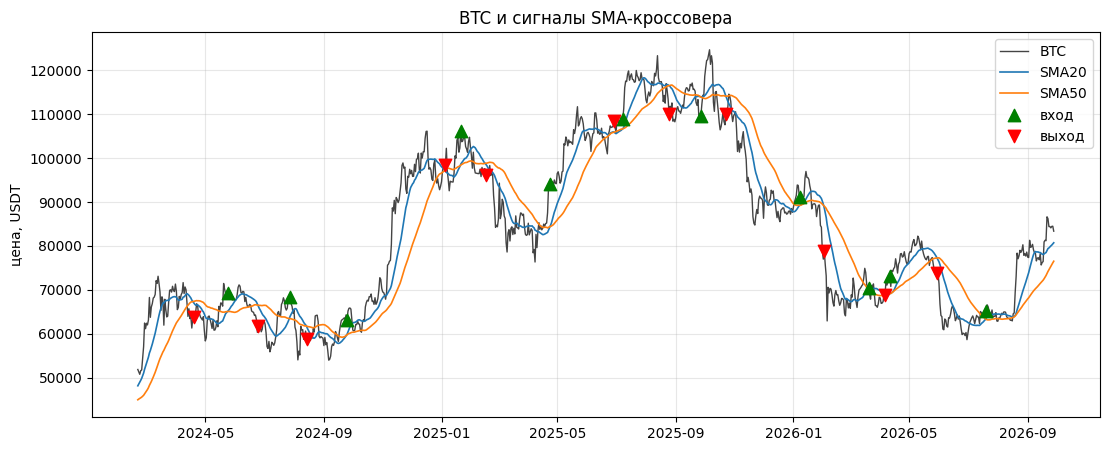

In [9]:
fig, ax = plt.subplots()
ax.plot(df.date, df.close, label='BTC', linewidth=1, color='#444')
ax.plot(df.date, df.sma_fast, label=f'SMA{FAST}', linewidth=1.2)
ax.plot(df.date, df.sma_slow, label=f'SMA{SLOW}', linewidth=1.2)

buys = df[df.cross == 1]
sells = df[df.cross == -1]
ax.scatter(buys.date, buys.close, marker='^', s=80, color='green', zorder=5, label='вход')
ax.scatter(sells.date, sells.close, marker='v', s=80, color='red', zorder=5, label='выход')

ax.set_title('BTC и сигналы SMA-кроссовера')
ax.set_ylabel('цена, USDT')
ax.legend()
plt.show()

## 4. Бэктест

Два момента, которые нельзя пропускать, иначе результат будет завышенным:

**Момент исполнения.** Сигнал считается по цене закрытия дня, но эту цену я узнаю только
когда день закончился. Войти можно не раньше следующего дня. Поэтому позиция сдвигается
на один шаг: `signal.shift(1)`. Без сдвига получается заглядывание в будущее — решение
принимается с уже известным результатом дня.

**Комиссия.** Спотовая сделка стоит около 0.1%. Списываю её в каждый день смены позиции.

In [10]:
FEE = 0.001   # 0.1% за сделку

df['ret'] = df['close'].pct_change().fillna(0)

# решение принято вчера по закрытию, исполняется сегодня
df['position'] = df['signal'].shift(1).fillna(0)

# смена позиции = сделка
df['trade'] = df['position'].diff().abs().fillna(0)

df['strategy_ret'] = df['position'] * df['ret'] - df['trade'] * FEE

df['equity'] = (1 + df['strategy_ret']).cumprod()
df['equity_hold'] = (1 + df['ret']).cumprod()

n_trades = int(df['trade'].sum())
print(f'сделок за период: {n_trades}')
print(f'суммарная комиссия: {n_trades * FEE * 100:.1f}% от капитала\n')
print(f"SMA-стратегия:  {(df.equity.iloc[-1] - 1) * 100:+.1f}%")
print(f"купил и держал: {(df.equity_hold.iloc[-1] - 1) * 100:+.1f}%")

сделок за период: 23
суммарная комиссия: 2.3% от капитала

SMA-стратегия:  +66.0%
купил и держал: +60.8%


## 5. Метрики

In [11]:
def metrics(returns, equity, name):
    years = len(returns) / 365
    total = equity.iloc[-1] - 1
    cagr = equity.iloc[-1] ** (1 / years) - 1
    dd = (equity / equity.cummax() - 1).min()
    sharpe = returns.mean() / returns.std() * np.sqrt(365) if returns.std() > 0 else 0
    return {
        'стратегия': name,
        'доходность, %': total * 100,
        'годовых, %': cagr * 100,
        'макс. просадка, %': dd * 100,
        'Sharpe': sharpe,
    }


table = pd.DataFrame([
    metrics(df.strategy_ret, df.equity, 'SMA 20/50'),
    metrics(df.ret, df.equity_hold, 'купил и держал'),
])
table

,стратегия,"доходность, %","годовых, %","макс. просадка, %",Sharpe
0,SMA 20/50,65.99,21.47,-38.59,0.74
1,купил и держал,60.77,19.99,-52.97,0.62


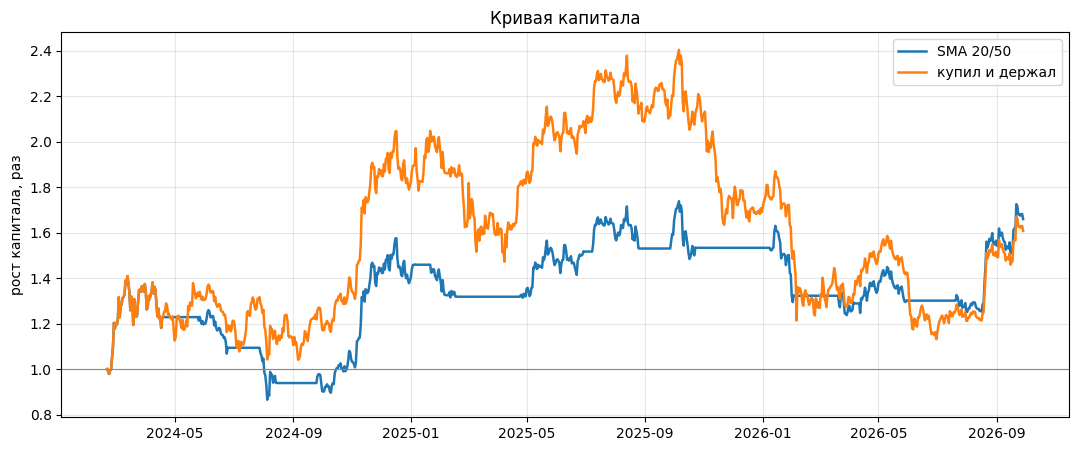

In [12]:
fig, ax = plt.subplots()
ax.plot(df.date, df.equity, label='SMA 20/50', linewidth=1.8)
ax.plot(df.date, df.equity_hold, label='купил и держал', linewidth=1.8)
ax.axhline(1, color='#888', linewidth=0.8)
ax.set_title('Кривая капитала')
ax.set_ylabel('рост капитала, раз')
ax.legend()
plt.show()

### Просадки

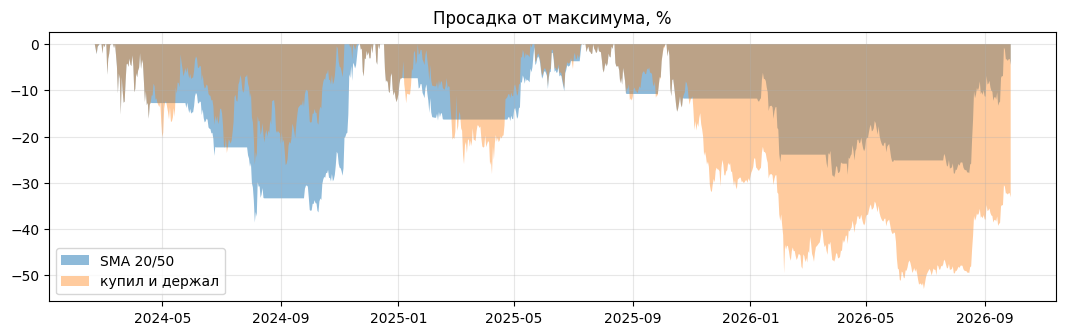

In [13]:
dd_strat = df.equity / df.equity.cummax() - 1
dd_hold = df.equity_hold / df.equity_hold.cummax() - 1

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.fill_between(df.date, dd_strat * 100, 0, alpha=0.5, label='SMA 20/50')
ax.fill_between(df.date, dd_hold * 100, 0, alpha=0.4, label='купил и держал')
ax.set_title('Просадка от максимума, %')
ax.legend()
plt.show()

## 6. Чувствительность к параметрам

20 и 50 взяты потому, что так принято. Проверяю, не случайность ли результат: перебираю
пары периодов и смотрю, есть ли устойчивая зона, где стратегия работает, или отдельные
удачные значения.

In [14]:
def backtest(data, fast, slow, fee=FEE):
    if fast >= slow:
        return np.nan
    d = data.copy()
    d['f'] = d['close'].rolling(fast).mean()
    d['s'] = d['close'].rolling(slow).mean()
    d = d.dropna(subset=['s'])
    pos = (d['f'] > d['s']).astype(int).shift(1).fillna(0)
    trade = pos.diff().abs().fillna(0)
    r = pos * d['close'].pct_change().fillna(0) - trade * fee
    return (1 + r).prod() - 1


fasts = [5, 10, 20, 30, 50]
slows = [20, 50, 100, 150, 200]

grid = pd.DataFrame(
    [[backtest(df, f, s) for s in slows] for f in fasts],
    index=[f'SMA{f}' for f in fasts],
    columns=[f'SMA{s}' for s in slows],
)
(grid * 100).round(1)

,SMA20,SMA50,SMA100,SMA150,SMA200
SMA5,-5.60,22.60,37.60,22.40,37.40
SMA10,-0.60,5.90,-0.80,18.10,24.30
SMA20,NaN,21.80,-2.30,9.80,32.60
SMA30,NaN,-13.00,8.50,3.10,36.50
SMA50,NaN,NaN,9.60,-1.40,0.90


## 7. Выводы

Конкретные цифры в таблице метрик выше, они зависят от периода, на котором запущен ноутбук.

**Про саму стратегию.** Скользящие средние по своей природе запаздывают: сигнал приходит
уже после того, как движение началось. На выраженном тренде это работает, на боковике
даёт серию ложных пересечений, каждое из которых стоит комиссии.

**Главный аргумент стратегии — не доходность, а просадка.** На графике просадок видно, что
выход из позиции по сигналу заметно смягчает падения: стратегия пересиживает обвалы в кэше.
Если сравнивать не голую доходность, а доходность на единицу риска, картина другая.

**Про подбор параметров.** В таблице чувствительности всегда найдётся пара, которая выстрелила.
Выбирать её по итоговой доходности — это подгонка под историю, на новых данных она развалится.
Смотреть надо на то, есть ли вообще зона устойчиво положительных значений, или хорошие цифры
разбросаны по таблице случайно.

**Что можно сделать дальше:** проверить на других монетах и других временных отрезках,
добавить стоп-лосс, протестировать на разных таймфреймах.